In [ ]:
# import libraries
import gsd.hoomd
import requests
import freud
import re
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from openmm import unit

In [ ]:
base_dir = os.getcwd()

# plot formatting
plt.style.use('seaborn-v0_8-paper')
color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
# Single column
fig_width = 3.375  # inches
fig_height = fig_width * 0.66  # keep ~4:3 ratio
plt.rcParams.update({
    "text.usetex": True,                   # Use LaTeX
    "font.family": "serif",                # Serif font
    "font.size": 8,                         # Global font size
    "axes.titlesize": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.figsize": (fig_width, fig_height),
    "figure.dpi": 300                       # High resolution
})

In [ ]:
# helper functions

def get_debye_length(file):
    """Extract debye length from ramp_update_reporter.csv"""
    df = pd.read_csv(file)
    debye_length = df['debye_length'].values if 'debye_length' in df.columns else None
    return debye_length

def get_cluster_sizes(trajectory_file, frame_index):
    """Extract largest cluster size from trajectory.gsd at a given frame"""
    with gsd.hoomd.open(trajectory_file, 'r') as traj:
        frame = traj[frame_index]
    
    box = frame.configuration.box
    positions = frame.particles.position
    radii = frame.particles.diameter / 2

    max_r, min_r = max(radii), min(radii)
    cutoff_distance = 1.2 * (max_r + min_r)

    freud_cluster = freud.cluster.Cluster()
    freud_cluster.compute((box, positions), neighbors={'r_max': cutoff_distance, "exclude_ii": True})

    unique, counts = np.unique(freud_cluster.cluster_idx, return_counts=True)
    return counts

# Introduction
This tutorial follows the cookbook from Höllmer 2026 for simulating polymer-attenuated Coulombic self-assembly. Each section of this tutorial details the most important parameters for running simulations similar to those specified in the Cookbook.

Before running molecular dynamics simulations, key quantities to examine for any given system are the integrator parameters, universal potential parameters, and individual particle parameters to ensure the modeled system corresponds to physical observations. For an explanation of each of the physical quantities used in this discussion, reference Hueckel 2020.

Notably, the temperature and potential temperature are specified separately. Potential temperture refers to any temperature in an interparticle potential, such as T highlighted in red below:

$$
    V_E = 2k_B\color{red}T\color{none}\pi\epsilon r\psi_1\psi_2\exp(-h/\lambda_D)
$$

The temperature supplied in the integrator parameters refers to any temperature used in the integrator function. In the case of the Verlet algorithm, the velocity update function is as follows:

$$
    m_i \frac{d\mathbf{v}_i}{dt} = \mathbf{f_i} - \gamma m_i \mathbf{v}_i + N(0, 2\gamma k_B \color{red}T\color{none})
$$

where $\mathbf{v}_i$ is the velocity on the $i^{th}$ particle, gamma is the friction coefficient (also specified in the integrator parameters), $m_i$ is the mass of the $i^{th}$ particle, $\mathbf{f_i}$ is the force on that particle, and $N(\mu, \sigma^2)$ is a normal distribution with mean $\mu$ and variance $\sigma^2$

These two temperatures need not be the same in principle, but selecting different values for them may generate non-physical results.

Below we list some parameters that generate a large single crystal of a CsCl-like colloidal crystal and elucidate how each of these parameters is used in the molecular dynamics algorithm.

### I - Integrator Parameters

The integrator parameters are used in the integrator algorithm. The main difference between the various integrators comes in their velocity update step. The velocity update step for the Langevin Integrator is shown below with each of the integrator parameters highlighted.

$$
    m_i \frac{d\mathbf{v}_i}{\color{red}dt\color{none}} = \mathbf{f_i} - \color{orange}\gamma\color{none} m_i \mathbf{v}_i + N(0, 2\color{orange}\gamma\color{none} k_B \color{yellow}T\color{none})
$$

- integrator: LangevinIntegrator

- integrator_parameters:
  - randomNumberSeed: 1

<font color=red>

  - stepSize: !Quantity
    - unit: picosecond
    - value: 0.00317647015905543
  
<font color=orange>

  - frictionCoeff: !Quantity
    - unit: /picosecond
    - value: 0.001574074286750681

<font color=yellow>

  - temperature: !Quantity
    - unit: kelvin
    - value: 298.0

## II - Potential Parameters
Potential parameters are exclusively used as global parameters in the openmm forces acting on the system. The screened Coulombic potential between two charged particles and the Alexander de Gennes polymer brush model that together define the PACS pair potential are given as an example that incorporates all of the specified potential parameters.

$$
    V_E = 2k_B\color{red}T\color{none}\pi\color{orange}\epsilon\color{none} r\psi_1\psi_2\exp(-h/\color{yellow}\lambda_D\color{none})
$$
$$
    V_P = \frac{16k_B\color{red}T\color{none} \pi L^2 \color{green}\sigma\color{none}^{\frac{3}{2}}}{35}\left[28\left(\left(\frac{h}{2\color{blue}L\color{none}}\right)^{-\frac{1}{4}}-1\right) + \frac{20}{11}\left(1-\left(\frac{h}{2\color{blue}L\color{none}}\right)^{\frac{11}{4}}+12\left(\frac{h}{2\color{blue}L\color{none}}-1\right)\right)\right]
$$

<font color=red>

- potential_temperature: !Quantity
  - unit: kelvin
  - value: 298.0

<font color=orange>

- dielectric_constant: 80.0

<font color=yellow>

- debye_length: !Quantity
  - unit: nanometer
  - value: 5.0483

<font color=green>

- brush_density: !Quantity
  - unit: /(nanometer**2)
  - value: 0.09

<font color=blue>

- brush_length: !Quantity
  - unit: nanometer
  - value: 10.0



## III - Individual Particle Parameters

Individual particle parameters correspond to per-particle parameters in openmm force objects, except for mass which is used in the integrator. These are specified in the configuration parameters yaml file, as they are necessary for creating the initial configuration.

$$
    \color{red}m_i\color{none} \frac{d\mathbf{v}_i}{dt} = \mathbf{f_i} - \gamma \color{red}m_i\color{none} \mathbf{v}_i + N(0, 2\gamma k_B T)
$$
$$
    V_E = 2k_BT\pi\epsilon \color{orange}r\color{none}\color{yellow}\psi_1\psi_2\color{none}\exp(-h/\lambda_D)
$$

<font color=red>

- masses:
    - "1": !Quantity
        - unit: dalton
        - value: 1.24898
    - "2": !Quantity
        - unit: dalton
        - value: 1.0

<font color=orange>

- radii:
    - "1": !Quantity
        - unit: nanometer
        - value: 105.0
    - "2": !Quantity
        - unit: nanometer
        - value: 97.5
        
<font color=yellow>

- surface_potentials:
    - "1": !Quantity
        - unit: millivolt
        - value: -50.0
    - "2": !Quantity
        - unit: millivolt
        - value: 50.0

# A - Nucleation
## I - Running a Classical Nucleation Simulation

Once we have specified all of these parameters, all we need to run a simple nucleation simulation is to first create our initial configuration of particles using colloids-create:

In [ ]:

os.chdir(f'{base_dir}/Nucleation/Classical')
!colloids-create configuration_parameters.yaml initial_configuration.gsd

Next, simply run the nucleation simulation using colloids-run:

In [ ]:
!colloids-run run_parameters.yaml

## II - Running a Nonclassical Nucleation Simulation

To run a nonclassical nucleation simulation, we change the size of the smaller particle so that our simultion goes through an intermediate aggregate state before crystallizing. We run at a slightly different Debye length. We choose this Debye length to ensure our system does not fail to crystalize due to a weak interaction strength or undergo irreversible floculation from too high of an interaction strength.

The configuration parameters are the same as in the classical nucleation simulation. Like before, the initial configuration is generated by using colloids-create:

In [ ]:
os.chdir(f'{base_dir}/Nucleation/Nonclassical')
!colloids-create configuration_parameters.yaml initial_configuration.gsd

For these simulations Debye length was slightly increased slightly beyond what is necessary to cause nucleation, causing multiple aggregates to form and encouranging two step nucleation.

The run parameters have been slightly modified to reflect this:

- debye_length: !Quantity
  - unit: nanometer
  - value: 5.2

Next, simply run the nucleation simulation using colloids-run:

In [ ]:
!colloids-run run_parameters.yaml

## III - Analysis

To see the difference between the two nucleation pathways, we can analyze the free energy as a function of simulation progress. 
In the classical case, we expect a single barrier to nucleation, while in the nonclassical case, we expect to see two barriers corresponding to the two-step nucleation process. 
In the nonclassical case the first barrier is the barrier between the gas phase and aggregate phase and the second is the barrier between the aggregate phase and the crystaline phase.
You can either wait for the simulations to finish or download the state data from our online repository.

In [ ]:
# Check if simulation files exist and are complete (10001 frames)
classical_state_data_file = f"{base_dir}/Nucleation/Classical/state_data.csv"
nonclassical_state_data_file = f"{base_dir}/Nucleation/Nonclassical/state_data.csv"

# Download state data files from the internet
try:
    df = pd.read_csv(classical_state_data_file)
    classical_download_required = 'debye_length' not in df.columns
    if not classical_download_required:
        n_frames = len(df['debye_length'])
        classical_download_required = n_frames < 5000
except:
    classical_download_required = True

try:
    df = pd.read_csv(nonclassical_state_data_file)
    nonclassical_download_required = 'debye_length' not in df.columns
    if not nonclassical_download_required:
        n_frames = len(df['debye_length'])
        nonclassical_download_required = n_frames < 10000
except:
    nonclassical_download_required = True
    
if classical_download_required:
    # Classical trajectory data
    classical_url = "https://docs.google.com/spreadsheets/d/167vLjVJQkFFs7IGOBbBUkpx3dsLpO4ShKS81fM6Ng3I/export?format=csv"
    classical_response = requests.get(classical_url)
    with open(classical_state_data_file, "wb") as f:
        f.write(classical_response.content)

if nonclassical_download_required:
    # Nonclassical trajectory data
    nonclassical_url = "https://drive.google.com/uc?export=download&id=19HLvjgvT9zatV667Uss9RjvFPkkdTSpO"
    nonclassical_response = requests.get(nonclassical_url)
    with open(nonclassical_state_data_file, "wb") as f:
        f.write(nonclassical_response.content)

Get the images associated with each of the two trajectories

In [ ]:
# Collect relative image paths from both images folders
nucleation_image_dirs = [
    os.path.join(os.path.dirname(classical_state_data_file), "images"),
    os.path.join(os.path.dirname(nonclassical_state_data_file), "images"),
]

valid_ext = (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp", ".gif", ".svg", ".webp")
image_paths = []

for folder in nucleation_image_dirs:
    if os.path.isdir(folder):
        for root, _, files in os.walk(folder):
            image_paths_unsorted = []
            for file in files:
                if file.lower().endswith(valid_ext):
                    image_paths_unsorted.append(os.path.relpath(os.path.join(root, file)))
            image_paths.extend(sorted(image_paths_unsorted, key=lambda x: int(re.search(r'(\d+)', os.path.basename(x)).group(1))))

print(f"Found {len(image_paths)} images.")

Now that we have the state data, simply plot the potential energy as a function of trajectory progress and insert our frame labeled images onto the plot.

In [ ]:
# Open both CSV files as pandas dataframes
classical_df = pd.read_csv(classical_state_data_file)
nonclassical_df = pd.read_csv(nonclassical_state_data_file)

# Extract energy columns from both dataframes
classical_energy = classical_df["Potential Energy (kJ/mole)"]
nonclassical_energy = nonclassical_df["Potential Energy (kJ/mole)"]

# Normalize simulation progress for both trajectories
classical_progress = classical_df['#"Time (ps)"']
nonclassical_progress = nonclassical_df['#"Time (ps)"']

n_particles = 6750  # Total number of particles in the system
classical_energy = classical_energy / n_particles
nonclassical_energy = nonclassical_energy / n_particles

# Create plot with both trajectories
plt.figure(figsize=(fig_width, fig_height))
plt.plot(classical_progress, classical_energy, color='blue', label='Classical Trajectory', linewidth=2)
plt.plot(nonclassical_progress, nonclassical_energy, color='red', label='Nonclassical Trajectory', linewidth=2)

label_font_size = 5

ax = plt.gca()

# (x, y, width, height) in axes coordinates
image_boxes = [
    (-0.04, 0.19, 0.28, 0.28),   # lower-left
    (0.15, 0.01, 0.28, 0.28),
    (0.45, 0.01, 0.36, 0.36),   # lower-right
    (0.695, 0.01, 0.36, 0.36),
    (0.2, 0.69, 0.3, 0.3),      # upper-center
    (0.38, 0.63, 0.3, 0.3),
    (0.56, 0.57, 0.3, 0.3),     # upper-center-right
    (0.74, 0.51, 0.3, 0.3),
]

# Add images to the plot
for i, (x, y, w, h) in enumerate(image_boxes):
    if image_paths:
        img_path = image_paths[i]
        color = 'red' if "nonclassical" in img_path.lower() else 'blue'
        img = plt.imread(img_path)
        ax_inset = ax.inset_axes([x, y, w, h])
        ax_inset.imshow(img)
        ax_inset.axis('off')
        ax_inset.text(0.14, 0.86, f"{i}", transform=ax_inset.transAxes,
                        fontsize=label_font_size, ha='center', va='center', color=color, fontweight='bold', bbox=dict(facecolor='white', edgecolor=color, boxstyle='circle'))

# Put labels from each inset image to its corresponding energy point
for i in range(min(len(image_boxes), len(image_paths))):
    x, y, w, h = image_boxes[i]
    path = image_paths[i]

    match = re.search(r"(\d+)", os.path.basename(path))
    if not match:
        continue

    color = 'red' if "nonclassical" in path.lower() else 'blue'
    mult_factor = 100 # There are 100 state data saves per trajectory frame.

    frame_idx = int(match.group(1)) * mult_factor

    # Select trajectory series based on image path
    if "nonclassical" in path.lower():
        p = nonclassical_progress
        e = nonclassical_energy
    else:
        p = classical_progress
        e = classical_energy

    # Use frame number as row index (clipped to valid range)
    idx = min(frame_idx, len(p) - 1)
    x_data = p.iloc[idx]
    y_data = e.iloc[idx]

    max_energy = ax.get_ylim()[1]
    min_energy = ax.get_ylim()[0]
    max_progress = ax.get_xlim()[1]
    min_progress = ax.get_xlim()[0]

    x_data_norm = (x_data - min_progress) / (max_progress - min_progress)
    y_data_norm = (y_data - min_energy) / (max_energy - min_energy)

    ax.text(x_data_norm, y_data_norm + 0.05, f"{i}", transform=ax.transAxes,
            fontsize=label_font_size, color=color, fontweight='bold', bbox=dict(facecolor='white', edgecolor=color, boxstyle='circle'))

y_ticks = np.int16(np.linspace(min_energy, max_energy, num=6))

plt.legend(loc='upper right', fontsize=4)
plt.yticks(y_ticks, labels=[f"{num}" for num in y_ticks])
plt.xlabel("Time (ps)")
plt.ylabel("Potential Energy Per Particle (kJ/mol)")
plt.gcf().set_dpi(1000)
plt.show()

# B - Stability

### I - Creating Stable Crystal Structure Initial Conditions

One may wish to examine the stability of possible crystal polymorphs before simulating. We have a framework that can create supercell crystal lattices with optimized potential energy from a candidate crystal structure. To use this feature create a CIF with the candidate crystal structure:

```
# generated using pymatgen
data_CsCl
_symmetry_space_group_name_H-M   'P 1'
_cell_length_a   4.14369834
_cell_length_b   4.14369834
_cell_length_c   4.14369834
_cell_angle_alpha   90.00000000
_cell_angle_beta   90.00000000
_cell_angle_gamma   90.00000000
_symmetry_Int_Tables_number   1
_chemical_formula_structural   CsCl
_chemical_formula_sum   'Cs1 Cl1'
_cell_volume   71.14827813
_cell_formula_units_Z   1
loop_
 _symmetry_equiv_pos_site_id
 _symmetry_equiv_pos_as_xyz
  1  'x, y, z'
loop_
 _atom_type_symbol
 _atom_type_oxidation_number
  Cs+  1.0
  Cl-  -1.0
loop_
 _atom_site_type_symbol
 _atom_site_label
 _atom_site_symmetry_multiplicity
 _atom_site_fract_x
 _atom_site_fract_y
 _atom_site_fract_z
 _atom_site_occupancy
  Cs+  Cs0  1  0.00000000  0.00000000  0.00000000  1
  Cl-  Cl1  1  0.50000000  0.50000000  0.50000000  1
```

Then use the LatticeBuilder configuration generator, referencing the cif file as the lattice specification argument. If `optimize_energy` is true, the value of spacing in between particles set in the radii padding factor argument is optimized to find the minimum energy configuration. 

- configuration_generator: LatticeBuilder
- configuration_generator_parameters:
  - lattice_specification: CsCl.cif
  - lattice_repeats: 6
  - run_parameters_file: run.yaml
  - radii_padding: !Quantity
    - unit: nanometer
    - value: 20.0 
  - lattice_padding: !Quantity
    - unit: nanometer
    - value: 412.61
  - optimize_energy: true

We show that for a 6x6x6 supercell generated from a CsCl lattice, the energy-optimized crystal is stable in a molecular dynamics simulation. Here we use an Update Reporter to ramp the temperature to help stabilize the crystal; see Section E - Dialysis for more details about update reporters.

In [ ]:
os.chdir(f'{base_dir}/Stability/Inputs')
!colloids-create configuration.yaml first_frame.gsd
!colloids-run run.yaml

# C - Seeding

## I - Running a Seeding Simulation

To investigate the growth and organization of colloidal crystals when nucleation is not an issue, we provide a simple method for introducing seed structures into your PACS simulations. We will use the seed file from the classical simulation. Download the trajectory with the following script. 

It would also be possible to run a similar experiment with synthetic crystals generated in the Stability section, above.

In [ ]:
import gsd.hoomd
import shutil
import os
import requests

# Check if simulation files exist and are complete (10001 frames)
os.chdir(f'{base_dir}/')
CsCl_trajectory_location = "Seeding/CsCl.gsd"
Th3P4_trajectory_location = "Seeding/Th3P4.gsd"

CsCl_url = "https://drive.google.com/uc?export=download&id=162hjaq5RKEIREVJrphoQ3FXOthcIQdeD"
CsCl_response = requests.get(CsCl_url)
with open(CsCl_trajectory_location, "wb") as f:
    f.write(CsCl_response.content)

Th3P4_url = "https://drive.google.com/uc?export=download&id=1Ss1vsmHks6Es4a7JrzCjhQW7xBd9gYY4"
Th3P4_response = requests.get(Th3P4_url)
with open(Th3P4_trajectory_location, "wb") as f:
    f.write(Th3P4_response.content)

Once we have this file we can use the following parameters to specify how to take the largest seed from each file and combine them in a simulation. In this simulation will be competing two large crystals against one another. To introduce the two seeds to the initial configuration, the following lines are added to the configuration parameters file.

- seed_filename: CsCl.gsd
    - overlap_distance: !Quantity
        - unit: nanometer
        - value: 230.0
    - cluster_cutoff_distance: !Quantity
        - unit: nanometer
        - value: 230.0
    - seed_fractional_position: [0.25, 0.25, 0.25]

- seed_filename: Th3P4.gsd
    - verlap_distance: !Quantity
      - unit: nanometer
      - value: 230.0
    - cluster_cutoff_distance: !Quantity
      - unit: nanometer
      - value: 230.0
    - seed_fractional_position: [0.75, 0.75, 0.75]

In [ ]:
!colloids-create configuration_parameters.yaml initial_configuration.gsd
!colloids-run run_parameters.yaml

### II - Analysis
Download the full seeded competition here if you don't want to wait for the simulation to complete.

In [ ]:
import gsd.hoomd
import shutil
import os
import requests

# Check if simulation files exist and are complete (101 frames)
competition_trajectory_location = f"{base_dir}/Seeding/trajectory.gsd"

try:
    # Check if the trajectory has at least 101 frames
    with gsd.hoomd.open(competition_trajectory_location, 'r') as f:
        n_frames = len(f)
    download_required = n_frames < 101
except:
    download_required = True

if download_required:
    # Download state data files from the internet
    # Classical trajectory data
    trajectory_url = "https://drive.google.com/uc?export=download&id=1BtcFyHW9mGqUK2Cjppv8MX2HWdRUkyyH"
    trajectory_response = requests.get(trajectory_url)
    with open(competition_trajectory_location, "wb") as f:
        f.write(trajectory_response.content)

Finally, we can show that the more 

In [ ]:
# Collect relative image paths from both images folders
seeding_image_dir = os.path.join(os.path.dirname(competition_trajectory_location), "images")

valid_ext = (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp", ".gif", ".svg", ".webp")
image_paths = []


for root, _, files in os.walk(seeding_image_dir):
    image_paths_unsorted = []
    for file in files:
        if file.lower().endswith(valid_ext):
            image_paths_unsorted.append(os.path.relpath(os.path.join(root, file)))
    image_paths.extend(sorted(image_paths_unsorted, key=lambda x: int(re.search(r'(\d+)', os.path.basename(x)).group(1))))

print(f"Found {len(image_paths)} images.")

In [ ]:

with gsd.hoomd.open(competition_trajectory_location, 'r') as f:
    n_frames = len(f)

cluster_sizes = []
for i in range(n_frames):
    cluster_sizes.append(get_cluster_sizes(competition_trajectory_location, i))

# Get the two largest clusters across all frames
max_clusters = 2

# Find the two largest clusters per frame and track them
cluster_sizes_sorted = [sorted(sizes, reverse=True) for sizes in cluster_sizes]
largest_cluster = [sizes[0] if len(sizes) > 0 else 0 for sizes in cluster_sizes_sorted]
second_largest_cluster = [sizes[1] if len(sizes) > 1 else 0 for sizes in cluster_sizes_sorted]

time_step = 0.0317647015 * (unit.pico * unit.second)
steps_per_frame = 10000000
time_ns = np.arange(n_frames) * time_step * steps_per_frame / (unit.pico * unit.second * 1e3)

# Plot with subplots
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

ax.plot(time_ns, largest_cluster, label='CsCl', linewidth=2, color='C0')
ax.plot(time_ns, second_largest_cluster, label='Th$_3$P$_4$', linewidth=2, color='C1')

ax.set_ylabel('Cluster Size')
ax.set_xlabel('Simulation Progress (ns)')
ax.legend()

label_font_size = 5
color = 'blue'

image_positions = [
    (1.0, 0.69, 0.35, 0.35),
    (1.0, 0.36, 0.35, 0.35),
    (1.0, 0.03, 0.35, 0.35),
    (1.0, -0.3, 0.35, 0.35),
]
# Add images to the plot
for i, (x, y, w, h) in enumerate(image_positions):
    if image_paths:
        img_path = image_paths[i]
        img = plt.imread(img_path)
        ax_inset = ax.inset_axes([x, y, w, h])
        ax_inset.imshow(img)
        ax_inset.axis('off')
        ax_inset.text(0.14, 0.86, f"{i}", transform=ax_inset.transAxes,
                        fontsize=label_font_size, ha='center', va='center', color=color, fontweight='bold', bbox=dict(facecolor='white', edgecolor=color, boxstyle='circle'))

#ax.set_xlim(min_progress, max_progress)
plt.tight_layout()

# Put labels from each inset image to its corresponding energy point
for i in range(len(image_positions)):
    x, y, w, h = image_positions[i]
    path = image_paths[i]

    match = re.search(r"(\d+)", os.path.basename(path))
    if not match:
        continue

    frame_idx = int(match.group(1))

    # Use frame number as row index (clipped to valid range)
    idx = min(frame_idx, len(time_ns) - 1)
    x_data = time_ns[idx]
    y_data = largest_cluster[idx]

    max_cluster_size = ax.get_ylim()[1]
    min_cluster_size = ax.get_ylim()[0]
    max_progress = ax.get_xlim()[1]
    min_progress = ax.get_xlim()[0]

    x_data_norm = (x_data - min_progress) / (max_progress - min_progress)
    y_data_norm = (y_data - min_cluster_size) / (max_cluster_size - min_cluster_size)

    ax.text(x_data_norm, y_data_norm, f"{i}", transform=ax.transAxes,
            fontsize=label_font_size, color=color, fontweight='bold', bbox=dict(facecolor='white', edgecolor=color, boxstyle='circle'))



plt.show()

# D - Substrates



### I - Simulation

Some crystals, such as Zangenite, only nucleate on a charged surface. Tuning the surface charge can direct growth of CsCl and Zangenite. 

We have implemented both implicit and explicit substrates that can be applied in colloids-run and colloids-create, repectively. 

An explicit substrate must be specified in the configuration parameters file as the surface is created out of immovable particles (zero mass by openmm covention).

- masses:
  - ...
  - "S": !Quantity
    - unit: dalton
    - value: 0.0
- radii:
  - ...
  - "S": !Quantity
    - unit: nanometer
    - value: 30.0
- surface_potentials:
  - ...
  - "S": !Quantity
    - unit: millivolt
    - value: -75.0
- initial_modifiers: 
    - "SubstrateModifier"
- initial_modifiers_parameters:
  - "substrate_type": "S"

Here is an example to generate a configuration and run a simulation with an explicit substrate wall. 

In [ ]:
os.chdir(f'{base_dir}/Substrate/ExplicitWallCharge75')
!colloids-create configuration_parameters.yaml first_frame.gsd
!colloids-run run_parameters.yaml

Using an explicit substrate can add a large amount of particles to the simulation, so it may be optimal for some applications to use an implicit substrate instead. This models the substrate as a charged plane and reduces the computational cost that would be required to explicitly model the substrate particles.

Experiment with the different implicit wall charges we provide to see the effect of wall charge on crystal growth.

Since using an implicit substrate does not add any actual particles to the simulation box, it does not affect configuration generation. Instead, it adds a force to the simulation, and therefore it must be specified in the run parameters.

- use_implicit_substrate: true
- substrate_wall_charge: !Quantity
    - unit: millivolt
    - value: -50.0

In [ ]:
os.chdir(f'{base_dir}/Substrate/ImplicitWallCharge75')
!colloids-create configuration_parameters.yaml initial_configuration.gsd
!colloids-run run_parameters.yaml

In [ ]:
os.chdir(f'{base_dir}/Substrate/ImplicitWallCharge50')
!colloids-create configuration_parameters.yaml initial_configuration.gsd
!colloids-run run_parameters.yaml

# E - Dialysis / Parameter Modulation

### I - Simulation

Some experimental procedures require dynamic forces. In simulation, this requires spatiotemporal variation of the pair potentials. This can be done in PACSim by specifying update reporters to update the value of potential-related variables as a simulation progresses. 

One example of this is a dialysis proceedure. During a dialysis simulation, the Debye length of the screened Coulombic potential is increased. This decreases the rate at which the Coulombic potential decays, increasing the interaction strength between charged colloids for all distances. This can be useful for finding the Debye Length that crystals start to nucleate at.

We have many schedules for update particle parameters, so we will demonstrate a basic update reporter and a cluster size based update reporter. The RampUpdateReporter linearly increases (or decreases) the value of a force-related parameter (in this case, debye length).

- update_reporter: RampUpdateReporter
- update_reporter_parameters:
  - filename: ramp_update_reporter.csv
  - parameter_name: debye_length
  - start_value: !Quantity
    - unit: nanometer
    - value: 4.5
  - end_value: !Quantity
    - unit: nanometer
    - value: 5.5
  - final_update_step: 100000000
  - update_interval: 1000000
  - print_interval: 1000000

In [ ]:
os.chdir(f'{base_dir}/Dialysis/BasicRamp')
!colloids-create configuration_parameters.yaml initial_configuration.gsd
!colloids-run run_parameters.yaml

The RampUpdateReporterUntilCluster caps once any aggregate is detected.

- update_reporter: RampUpdateReporterUntilCluster
- update_reporter_parameters:
  - filename: ramp_update_reporter.csv
  - parameter_name: debye_length
  - start_value: !Quantity
    - unit: nanometer
    - value: 4.5
  - end_value: !Quantity
    - unit: nanometer
    - value: 5.5
  - final_update_step: 100000000
  - cluster_size: 20
  - cutoff_distance: !Quantity
    - unit: nanometer
    - value: 230.0
  - update_interval: 1000000
  - print_interval: 1000000
  - check_interval: 1000000

In [ ]:
os.chdir(f'{base_dir}/Dialysis/ClusterRamp')
!colloids-create configuration_parameters.yaml initial_configuration.gsd
!colloids-run run_parameters.yaml

### II - Analysis
Load any files needed from the internet.

In [87]:
# Check if update reporter files exist
basic_update_reporter_file = f"{base_dir}/Dialysis/BasicRamp/ramp_update_reporter.csv"
cluster_update_reporter_file = f"{base_dir}/Dialysis/ClusterRamp/ramp_update_reporter.csv"

try:
    df = pd.read_csv(basic_update_reporter_file)
    basic_update_reporter_download_required = 'debye_length' not in df.columns
    if not basic_update_reporter_download_required:
        n_frames = len(df['debye_length'])
        basic_update_reporter_download_required = n_frames < 101
except:
    basic_update_reporter_download_required = True

try:
    df = pd.read_csv(cluster_update_reporter_file)
    cluster_update_reporter_download_required = 'debye_length' not in df.columns
    if not cluster_update_reporter_download_required:
        n_frames = len(df['debye_length'])
        cluster_update_reporter_download_required = n_frames < 101
except:
    cluster_update_reporter_download_required = True

# Download update reporter files from the internet
if basic_update_reporter_download_required:
    # Basic trajectory data
    basic_url = "https://drive.google.com/uc?export=download&id=1XN7y1zDL2Lsxg1z73oHM6hlCmlfOL-Nf"
    basic_response = requests.get(basic_url)
    with open(basic_update_reporter_file, "wb") as f:
        f.write(basic_response.content)

if cluster_update_reporter_download_required:
    # Cluster trajectory data
    cluster_url = "https://drive.google.com/uc?export=download&id=15kB7d7oLUWh4d2Lpbyh1pi_sE9182zFS"
    cluster_response = requests.get(cluster_url)
    with open(cluster_update_reporter_file, "wb") as f:
        f.write(cluster_response.content)

# Check if trajectory files exist
basic_trajectory_file = f"{base_dir}/Dialysis/BasicRamp/trajectory.gsd"
cluster_trajectory_file = f"{base_dir}/Dialysis/ClusterRamp/trajectory.gsd"

# Check if trajectory files have at least 101 frames, if not, download them from the internet
try:
    with gsd.hoomd.open(basic_trajectory_file, 'r') as f:
        basic_n_frames = len(f)
    basic_requires_download = basic_n_frames < 101
except:
    basic_requires_download = True

try:
    with gsd.hoomd.open(cluster_trajectory_file, 'r') as f:
        cluster_n_frames = len(f)
    cluster_requires_download = cluster_n_frames < 101
except:
    cluster_requires_download = True

if cluster_requires_download:
    # Cluster trajectory data
    cluster_url = "https://drive.google.com/uc?export=download&id=113899_D7H5O9XXe5Py0NsjlywdiiIqL4"
    cluster_response = requests.get(cluster_url)
    with open(cluster_trajectory_file, "wb") as f:
        f.write(cluster_response.content)

if basic_requires_download:
    basic_url = "https://drive.google.com/uc?export=download&id=1ajx7WBVzBCvLYN0eZKB0xha635Jdf35S"
    basic_response = requests.get(basic_url)
    with open(basic_trajectory_file, "wb") as f:
        f.write(basic_response.content)

# Collect relative image paths from both images folders
nucleation_image_dirs = [
    os.path.join(os.path.dirname(basic_update_reporter_file), "images"),
    os.path.join(os.path.dirname(cluster_update_reporter_file), "images"),
]

valid_ext = (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp", ".gif", ".svg", ".webp")
image_paths = []

for folder in nucleation_image_dirs:
    if os.path.isdir(folder):
        for root, _, files in os.walk(folder):
            image_paths_unsorted = []
            for file in files:
                if file.lower().endswith(valid_ext):
                    image_paths_unsorted.append(os.path.relpath(os.path.join(root, file)))
            image_paths.extend(sorted(image_paths_unsorted, key=lambda x: int(re.search(r'(\d+)', os.path.basename(x)).group(1))))

print(f"Found {len(image_paths)} images.")

Found 2 images.


We will plot how our update reporter changes the debye length changes as a function of time and the largest cluster size. When the Debye length is capped after crystals start to form, this prevents the simulation entering a regime where nucleation outpaces growth and many small crystal form, encouraging the formation of fewer, large crystals.

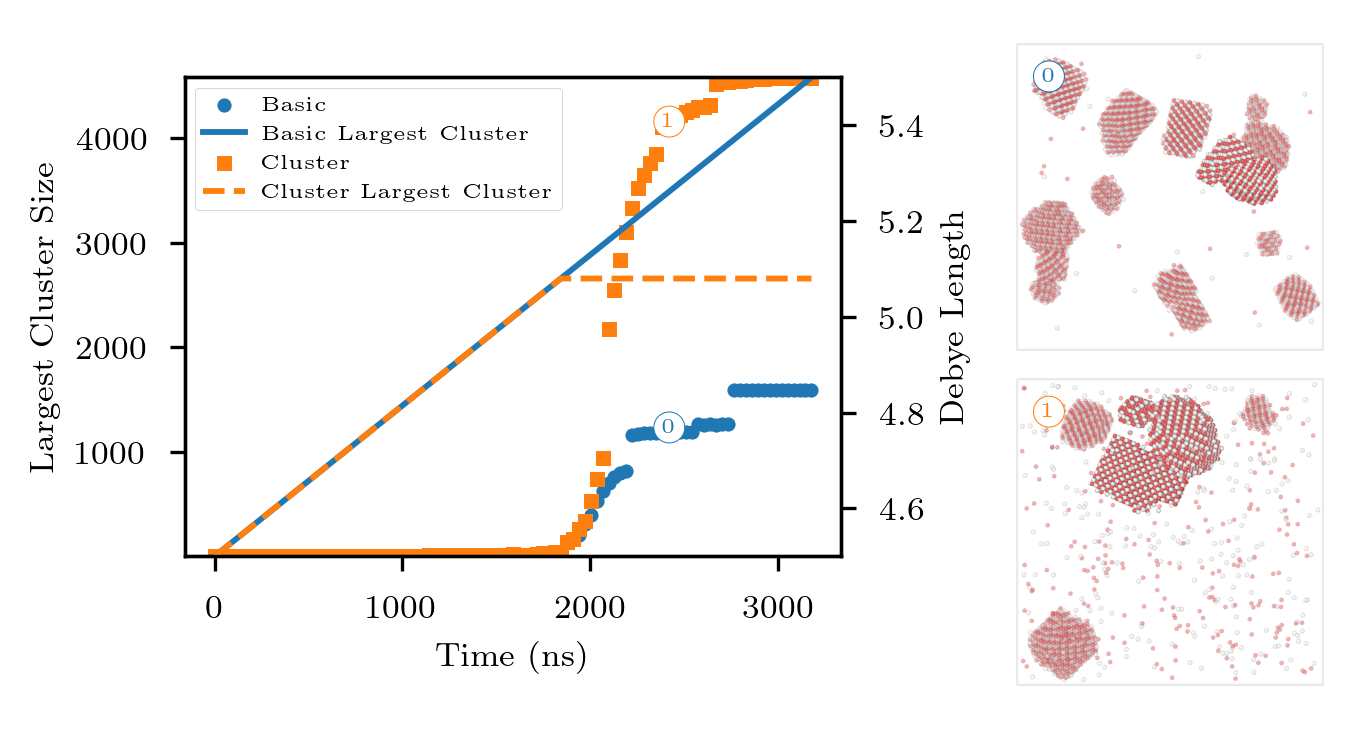

In [98]:
# Process both folders
fig, ax = plt.subplots()

names = ["Basic", "Cluster"]
update_reporter_files = [basic_update_reporter_file, cluster_update_reporter_file]
trajectory_files = [basic_trajectory_file, cluster_trajectory_file]

all_debye_lengths = []
all_cluster_sizes = []
for name, update_reporter_file, trajectory_file in zip(names, update_reporter_files, trajectory_files):
    # Get debye length
    debye_length = get_debye_length(update_reporter_file)
    all_debye_lengths.append(debye_length)

    # Get largest cluster size
    with gsd.hoomd.open(trajectory_file, 'r') as traj:
        n_frames = len(traj)
    cluster_sizes = []
    for i in range(n_frames):
        cluster_sizes.append(max(get_cluster_sizes(trajectory_file, i)))
    all_cluster_sizes.append(cluster_sizes)

max_debye_length = max([max(dl) for dl in all_debye_lengths if dl is not None])
min_debye_length = min([min(dl) for dl in all_debye_lengths if dl is not None])
max_cluster_size = max([max(cs) for cs in all_cluster_sizes])
min_cluster_size = min([min(cs) for cs in all_cluster_sizes])

ax1 = ax.twinx()

ax1.set_ylim(min_debye_length, max_debye_length)
ax.set_ylim(min_cluster_size, max_cluster_size)

line_styles = ['-', '--']  # Circle for Cluster Ramp, Square for Basic Ramp
marker_styles = ['o', 's']  # Circle for Cluster Ramp, Square for Basic Ramp

for i, (folder_name, line_style, marker_style) in enumerate(zip(names, line_styles, marker_styles)):
    step_size = 0.0317647015 * (unit.pico * unit.second) 
    steps_per_frame = 1000000
    time_ns = np.arange(n_frames) * step_size * steps_per_frame / (unit.pico * unit.second * 1e3)
    cluster_sizes = all_cluster_sizes[i]
    debye_length = all_debye_lengths[i]

    # Plot
    ax.scatter(time_ns, cluster_sizes, marker=marker_style, label=folder_name, color='C0' if i == 0 else 'C1', s=10)
    ax.plot([], [], linestyle=line_style, color='C0' if i == 0 else 'C1', label=f"{folder_name} Largest Cluster")
    ax1.plot(time_ns, debye_length, linestyle=line_style, label=f"{folder_name} Debye Length", color='C0' if i == 0 else 'C1')

ax.legend(loc='upper left', fontsize=5)
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Largest Cluster Size")
ax1.set_ylabel("Debye Length")
plt.tight_layout()

label_font_size = 5
color = 'blue'

image_positions = [
    (1.15, 0.4, 0.7, 0.7),
    (1.15, 0.-0.3, 0.7, 0.7),
]
# Add images to the plot
for i, (x, y, w, h) in enumerate(image_positions):
    if image_paths:
        img_path = image_paths[i]
        color = 'C0' if "basic" in img_path.lower() else 'C1'
        img = plt.imread(img_path)
        ax_inset = ax.inset_axes([x, y, w, h])
        ax_inset.imshow(img)
        ax_inset.axis('off')
        ax_inset.text(0.14, 0.86, f"{i}", transform=ax_inset.transAxes,
                        fontsize=label_font_size, ha='center', va='center', color=color, fontweight='bold', bbox=dict(facecolor='white', edgecolor=color, boxstyle='circle'))


# Put labels from each inset image to its corresponding energy point
for i in range(len(image_positions)):
    x, y, w, h = image_positions[i]
    path = image_paths[i]

    match = re.search(r"(\d+)", os.path.basename(path))
    if not match:
        continue

    frame_idx = int(match.group(1))
    cluster_sizes = all_cluster_sizes[i]
    color = 'C0' if "basic" in path.lower() else 'C1'

    # Use frame number as row index (clipped to valid range)
    idx = min(frame_idx, len(time_ns) - 1)
    x_data = time_ns[idx]
    y_data = cluster_sizes[idx]

    max_cluster_size = ax.get_ylim()[1]
    min_cluster_size = ax.get_ylim()[0]
    max_progress = ax.get_xlim()[1]
    min_progress = ax.get_xlim()[0]

    x_data_norm = (x_data - min_progress) / (max_progress - min_progress)
    y_data_norm = (y_data - min_cluster_size) / (max_cluster_size - min_cluster_size)

    ax.text(x_data_norm, y_data_norm, f"{i}", transform=ax.transAxes,
            fontsize=label_font_size, color=color, fontweight='bold', bbox=dict(facecolor='white', edgecolor=color, boxstyle='circle'))

plt.show()

# F - Clusters

Include if suitable example generated in future.

# G - Plumed

### I - Simulation

 Our PACSim software interfaces with plumed via the openmm-plumed plugin. We illustrate this functionality by calculating the mean coordination number of the colloidal particles on-the-fly with Plumed in a molecular dynamics simulation, where the system starts in the gas phase and forms a crystal. 

 We use a 432-particle binary system with negative (N) and positive (P) particles in a 1:1 ratio and we choose a pair potential interaction strength that facilitates crystal nucleation. We vary the Debye screening length parameter slightly and run three different simulations.

The Plumed parameters specified in the run parameters input file simply point towards a plumed script:
- use_plumed: true
- plumed_script: plumed.dat

In this example we look at the coordination number of each species. The plumed script is shown below:

```
UNITS LENGTH=nm TIME=ps ENERGY=kj/mol

#https://www.plumed.org/doc-master/user-doc/html/COORDINATIONNUMBER/

c_all: COORDINATIONNUMBER SPECIES=@mdatoms                  SWITCH={EXP D_0=300.0 R_0=50 D_MAX=600} MEAN

c_N_N: COORDINATIONNUMBER SPECIESA=1-432:2 SPECIESB=1-432:2 SWITCH={EXP D_0=300.0 R_0=50 D_MAX=600} MEAN

c_P_P: COORDINATIONNUMBER SPECIESA=2-432:2 SPECIESB=2-432:2 SWITCH={EXP D_0=300.0 R_0=50 D_MAX=600} MEAN

c_N_P: COORDINATIONNUMBER SPECIESA=1-432:2 SPECIESB=2-432:2 SWITCH={EXP D_0=300.0 R_0=50 D_MAX=600} MEAN

PRINT ARG=c_all.mean,c_N_N.mean,c_P_P.mean,c_N_P.mean, FILE=colvars STRIDE=10000
```


In [ ]:
os.chdir(f'{base_dir}/Plumed/Inputs')

In [ ]:
# generate a configuration
!colloids-create configuration_parameters.yaml first_frame.gsd

# run molecular dynamics simulation with debye 5.25 nm
!colloids-run run_parameters_debye5.25.yaml

# input files for debye lengths of 5.3 nm and 5.4 nm are also included in this same folder
# simply change the name of the .yaml file in the above command to run these


### II - Analysis


In [ ]:
os.chdir(f'{base_dir}/Plumed/Outputs')

f = np.loadtxt('colvars_debye5.25', unpack=True)
g = np.loadtxt('colvars_debye5.3', unpack=True)
h = np.loadtxt('colvars_debye5.4', unpack=True)

fig, ax = plt.subplots(figsize=(2*3.375, 4.0))  

ax.plot(f[0]/1e6, f[1], label='Debye = 5.25', color='blue')
ax.plot(g[0]/1e6, g[1], label='Debye = 5.3', color='gray')
ax.plot(h[0]/1e6, h[1], label='Debye = 5.4', color='orange')
ax.set_xlabel('Time ($\mu$s)')
ax.set_ylabel('Mean Coordination Number')
ax.legend()
plt.show()

We observe that as the Debye screening length increases and the pair potential grows stronger, the nucleation occurs sooner and the mean coordination number increases more sharply at the beginning of the simulation.

# H - Metadynamics

### I - Simulation

In addition to calculating the value of a collective variable on-the-fly during a simulation, the Plumed plugin can be used to run enhanced sampling molecular dynamics simulations by adding bias along a collective variable. In terms of the logistics of running such a simulation with our PACSim software, the inputs are exactly the same, but here the plumed script includes additional information to specify the bias.

We illustrate this functionality by running a simple well-tempered metadynamics simulation on the same binary 432-particle system, biasing along the mean coordination number of all particles. 

For this simulation, the run parameters point to our new metadynamics plumed script, and the plumed script is show here:

```
UNITS LENGTH=nm TIME=ps ENERGY=kj/mol
#https://www.plumed.org/doc-master/user-doc/html/COORDINATIONNUMBER/

c_all: COORDINATIONNUMBER SPECIES=@mdatoms SWITCH={EXP D_0=300.0 R_0=50 D_MAX=400} MEAN

METAD ...
  ARG=c_all.mean
  CALC_RCT
  HEIGHT=1.0
  BIASFACTOR=50
  SIGMA=0.5
  PACE=100
  TEMP=300
  GRID_MIN=0
  GRID_MAX=20
  GRID_BIN=201
  GRID_WFILE=grid.dat
  FILE=hills.dat
  GRID_WSTRIDE=10000
  LABEL=metad
  STRIDE=2
... METAD

PRINT ARG=c_all.mean,metad.* FILE=bias STRIDE=10000
```

In [ ]:
os.chdir(f'{base_dir}/Metadynamics/Inputs')

In [ ]:
# generate a configuration
!colloids-create configuration_parameters.yaml first_frame.gsd

# run a well-tempered metadynamics simulation, biasing the coordination number
!colloids-run run_parameters_with_bias.yaml

# to see the effect of the bias, we also ran an unbiased simulation for the same interaction strength and computed the CN on-the-fly
# to run the unbiased simulation, simply change the name of the .yaml file in the above command to run_parameters_unbiased.yaml


### II - Analysis

In [ ]:
os.chdir(f'{base_dir}/Metadynamics/Outputs')

In [ ]:
cv_file_metad = "bias"
cv_data_metad = np.loadtxt(cv_file_metad)

cv_file_unbiased = "colvars"
cv_data_unbiased = np.loadtxt(cv_file_unbiased)

plt.plot(cv_data_metad[:,0]/1e6,cv_data_metad[:,1], label='MetaD')
plt.plot(cv_data_unbiased[:,0]/1e6,cv_data_unbiased[:,1], label='Unbiased')
plt.legend(loc=0,ncol=3)
plt.ylim(0,15)
plt.xlabel("Time ($\mu$s)")
plt.ylabel("Coordination Number, $CN$")

plt.tight_layout()

plt.show()